In [8]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import time

import richio
from richio import shockfinder as sf
import nb, dev

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
np.log10(sf.MP2P1(M=1.3))

np.float64(0.27009628142033043)

## 1. Load snapshot

In [2]:
snap = richio.load(
    "/home/hey4/rich_tde/data/external/R0.47M0.5BH10000beta1S60Compton/snap_full_361.h5"
)
# snap.info()

In [3]:
snap.time.in_units("day")

unyt_array([5.7621411], 'day')

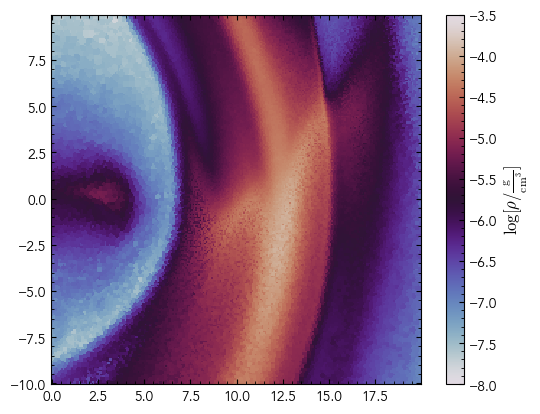

In [4]:
ax, im, _ = snap.plots.slice(
    "density",
    box_size=[0, -10, 20, 10],
    res=256,
    label_latex=r"\rho",
)
plt.show()

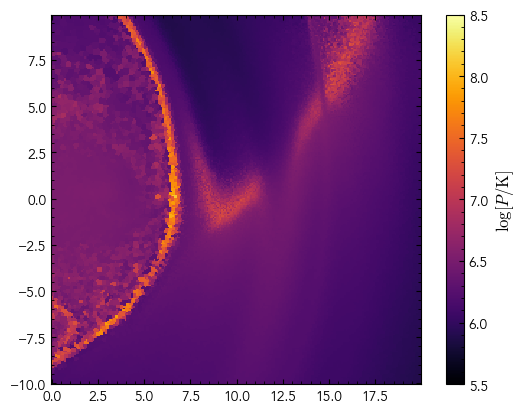

In [5]:
ax, im, _ = snap.plots.slice(
    "temperature",
    box_size=[0, -10, 20, 10],
    res=256,
    label_latex=r"P",
    cmap="inferno",
)
plt.show()

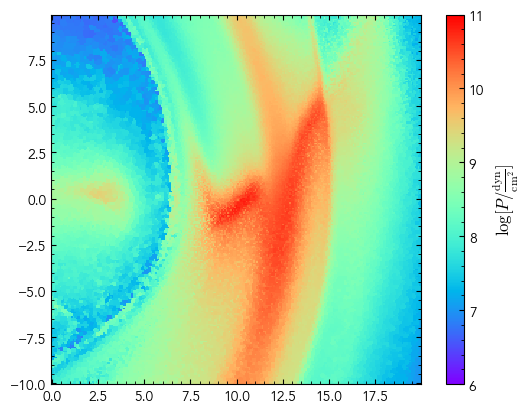

In [6]:
ax, im, _ = snap.plots.slice(
    "pressure",
    box_size=[0, -10, 20, 10],
    res=256,
    label_latex=r"P",
    cmap="rainbow",
)
plt.show()

/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/unyt/array.py:1832: RuntimeWarning: invalid value encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


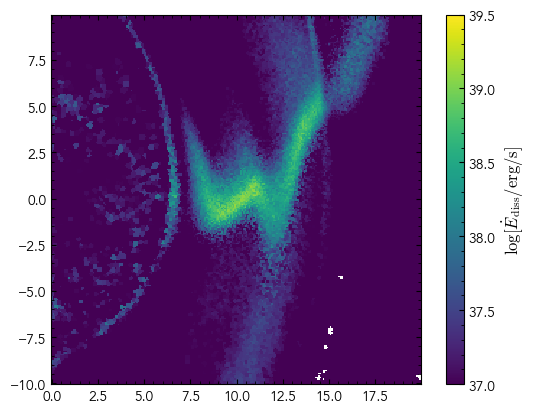

In [7]:
ax, im, _ = snap.plots.slice(
    snap.dissipation * snap.volume,
    box_size=[0, -10, 20, 10],
    res=256,
    cmap="viridis",
    label_latex=r"\dot E_{\rm diss}",
    vmin=37,
)
plt.show()

## 2. Build k-NN graph (candidate cells only)

<!-- The neighbour graph is only ever queried for the **condition 1 & 2 candidates**
(`∇·v < 0` and `∇T·∇P > 0`) — `_condition3_kernel` runs on them and the surface
ray tracer only walks within the shock zone (a subset). So we compute that
candidate set first and build k-NN rows for just those cells (≈¼ of the box on
TDE data), cutting query time and graph memory ~4×.

This stores a *k*-nearest-neighbour adjacency in CSR format — a clustering-robust,
memory-light drop-in for the global Voronoi build (`sf.build_voronoi`). The
analytical next-cell kernel recovers the Voronoi face per query, so `k`
neighbours (default 48) reproduce the exact-Voronoi shock catalogue while scaling
to the ~80M-cell hi-res runs the full tessellation cannot fit. Built on the full
snapshot so cell indices stay aligned with the snapshot fields. -->

In [8]:
# Candidates = conditions 1 & 2 (the only cells whose neighbours are ever used)
cand = sf.shock_candidates(snap)
print(
    f"Candidates: {len(cand.candidates):,} / {len(snap):,}  ({len(cand.candidates) / len(snap) * 100:.1f}%)"
)

Candidates: 4,118,154 / 17,447,778  (23.6%)


In [9]:
t0 = time.perf_counter()
vor = sf.build_knn(snap, cells=cand.candidates, k=48)
print(f"Built in {time.perf_counter() - t0:.1f} s")

Building k-NN graph (k=48) for 4,118,154 / 17,447,778 cells ...
Done.  48 neighbours/cell.
Built in 43.8 s


/home/hey4/.conda/envs/richanalysis/lib/python3.13/site-packages/unyt/array.py:1832: RuntimeWarning: divide by zero encountered in log10
  out_arr = func(np.asarray(inp), out=out_func, **kwargs)


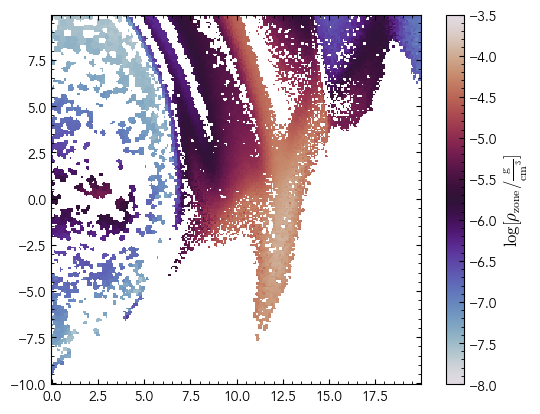

In [10]:
rho_cand = np.zeros_like(snap.density)
rho_cand[cand.candidates] = snap.density[cand.candidates]
ax, im, _ = snap.plots.slice(
    data=rho_cand,
    # box_size=[-3000, -2000, 1000, 1000],
    box_size=[0, -10, 20, 10],
    res=256,
    label_latex=r"\rho_{\rm zone}",
    vmin=-8,
    vmax=-3.5,
)

## 3. Shock zone

Three criteria from Schaal+15:
1. Converging flow: ∇·v < 0
2. Pressure gradient aligned with temperature gradient: ∇T·∇P > 0
3. Measurable T and P jump across the Voronoi face: Δlog T ≥ 0.11, Δlog P ≥ 0.27

In [11]:
t0 = time.perf_counter()
shock_zone = sf.find_shock_zone(snap, vor)
print(f"{shock_zone.sum():,} shock-zone cells  ({time.perf_counter() - t0:.2f} s)")

434,463 shock-zone cells  (13.71 s)


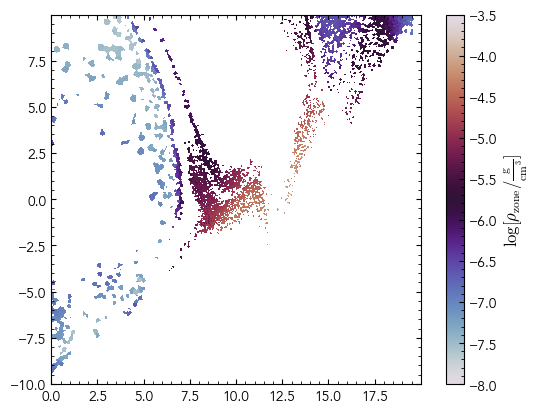

In [12]:
ax, im, _ = snap.plots.slice(
    snap.density * shock_zone,
    # box_size=[-3000, -2000, 1000, 1000],
    box_size=[0, -10, 20, 10],
    res=1024,
    label_latex=r"\rho_{\rm zone}",
    vmin=-8,
    vmax=-3.5,
)
plt.show()

## 4. Shock surface & Mach numbers

For each shock-zone cell, rays are traced along ±ds through the Voronoi graph
until exiting the zone. Mach numbers follow from the Rankine-Hugoniot T, P, ρ jumps.

In [13]:
t0 = time.perf_counter()
result = sf.find_shock_surface(snap, vor, shock_zone)
print(
    f"{result.surface_mask.sum():,} surface cells  ({time.perf_counter() - t0:.2f} s)"
)
print(
    f"Median Mach  T={np.median(result.mach_T):.2f}  P={np.median(result.mach_P):.2f}  rho={np.median(result.mach_rho):.2f}"
)

235,724 surface cells  (7.55 s)
Median Mach  T=2.40  P=1.68  rho=1.13


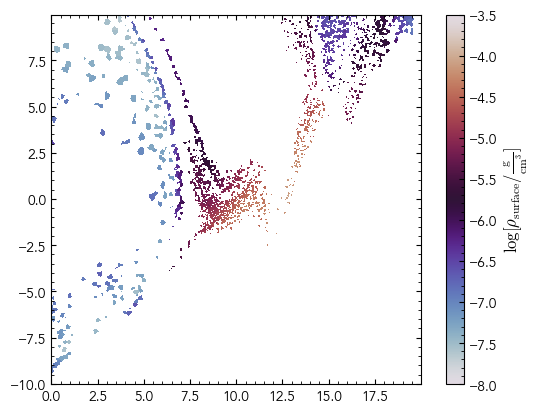

In [14]:
ax, im, _ = snap.plots.slice(
    snap.density * result.surface_mask,
    res=512,
    label_latex=r"\rho_{\rm surface}",
    box_size=[0, -10, 20, 10],
    vmin=-8,
    vmax=-3.5,
)
plt.show()

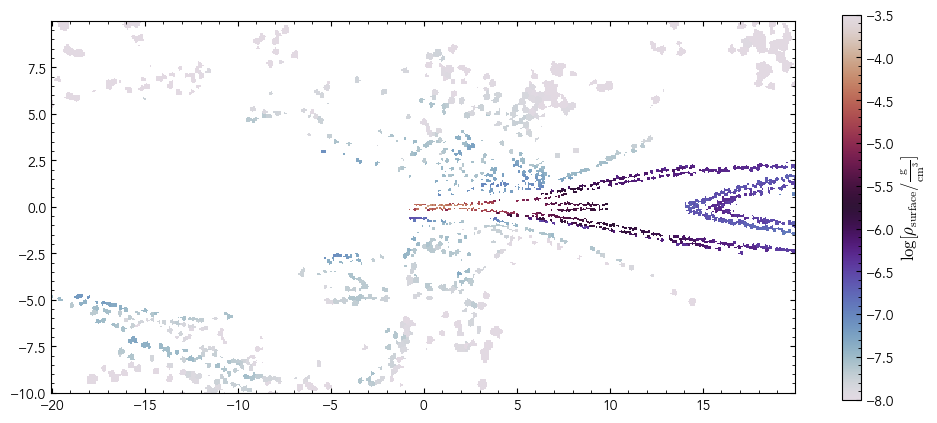

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax, im, _ = snap.plots.slice(
    snap.density * result.surface_mask,
    res=512,
    label_latex=r"\rho_{\rm surface}",
    box_size=[-20, -10, 20, 10],
    plane="yz",
    slice_coord=13,
    vmin=-8,
    vmax=-3.5,
    ax=ax,
)
plt.show()

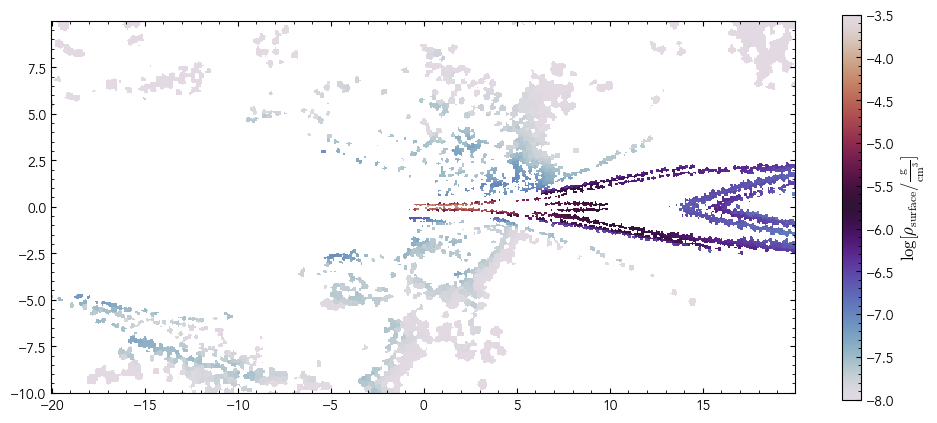

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax, im, _ = snap.plots.slice(
    snap.density * shock_zone,
    res=512,
    label_latex=r"\rho_{\rm surface}",
    box_size=[-20, -10, 20, 10],
    plane="yz",
    slice_coord=13,
    vmin=-8,
    vmax=-3.5,
    ax=ax,
)
plt.show()

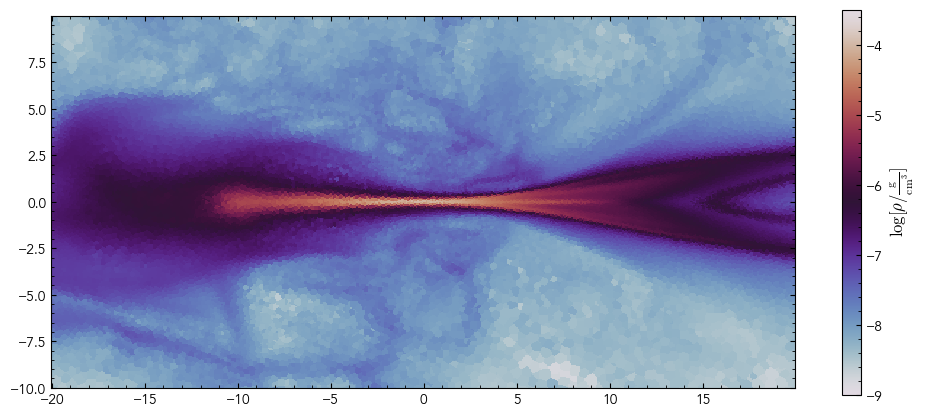

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax, im, _ = snap.plots.slice(
    "density",
    res=512,
    box_size=[-20, -10, 20, 10],
    plane="yz",
    slice_coord=13,
    ax=ax,
    label_latex=r"\rho",
    # vmin=37,
)
plt.show()

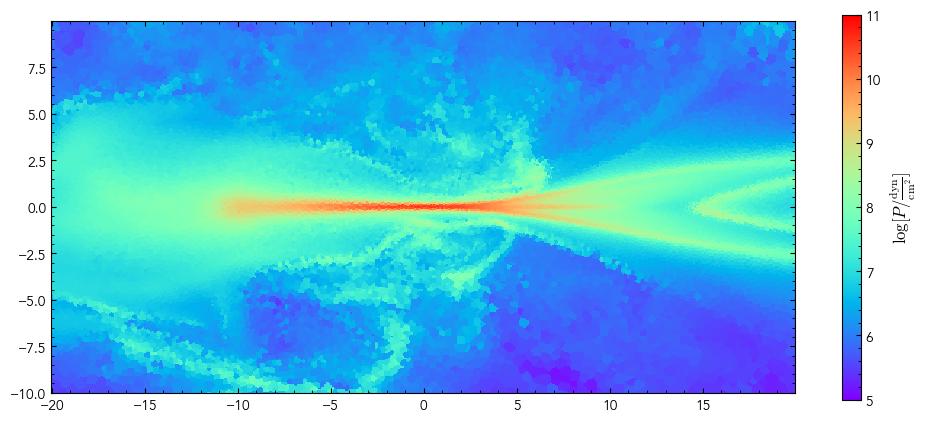

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax, im, _ = snap.plots.slice(
    "pressure",
    res=512,
    box_size=[-20, -10, 20, 10],
    plane="yz",
    slice_coord=13,
    ax=ax,
    label_latex=r"P",
    cmap="rainbow",
)
plt.show()

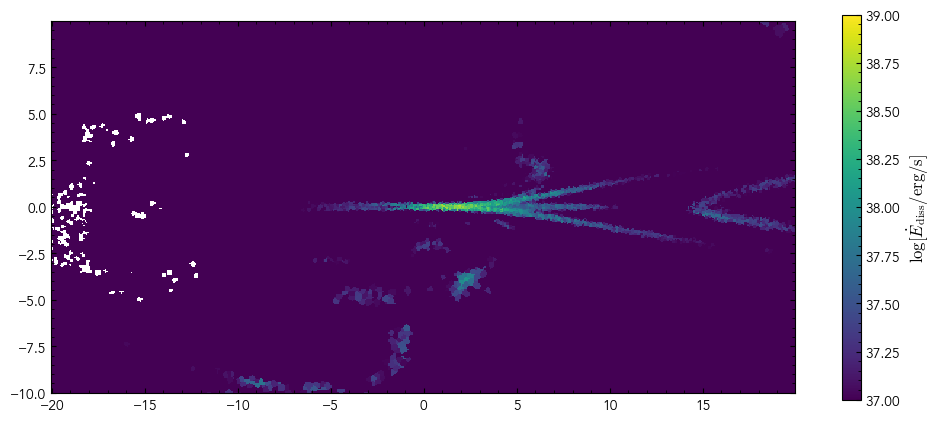

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax, im, _ = snap.plots.slice(
    snap.dissipation * snap.volume,
    res=512,
    box_size=[-20, -10, 20, 10],
    plane="yz",
    slice_coord=13,
    ax=ax,
    cmap="viridis",
    label_latex=r"\dot E_{\rm diss}",
    vmin=37,
)
plt.show()

In [20]:
dissipation = snap.dissipation * snap.volume
print("Shock surface dissipation", np.sum(dissipation * result.surface_mask).in_cgs())
print("Shock zone dissipation", np.sum(dissipation * shock_zone).in_cgs())
print("Total dissipation", np.sum(dissipation).in_cgs())

Shock surface dissipation 2.2966306969604753e+42 erg/s
Shock zone dissipation 3.5409080629221405e+42 erg/s
Total dissipation 9.625472313391406e+42 erg/s


## 5. Mach number distributions

M_T    n=235724  finite=235724  min=1.08  med=2.40  max=763.37
M_P    n=235724  finite=235724  min=0.48  med=1.68  max=56.81
M_rho  n=235724  finite=235724  min=0.00  med=1.13  max=276.15


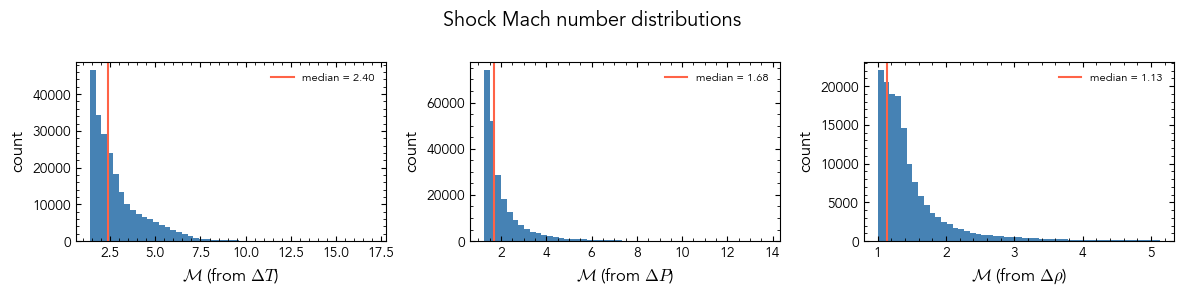

In [22]:
# Quick diagnostics — helps catch unit/scale surprises
for M, label in zip([result.mach_T, result.mach_P, result.mach_rho], ["T", "P", "rho"]):
    finite = M[np.isfinite(M)]
    print(
        f"M_{label:3s}  n={len(M):5d}  finite={len(finite):5d}  "
        f"min={finite.min():.2f}  med={np.median(finite):.2f}  max={finite.max():.2f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, M, label in zip(
    axes, [result.mach_T, result.mach_P, result.mach_rho], ["T", "P", r"\rho"]
):
    finite = M[np.isfinite(M)]
    lo, hi = max(1, np.percentile(finite, 1)), np.percentile(finite, 99)
    bins = np.linspace(lo, hi, 50)
    ax.hist(finite, bins=bins, color="steelblue", edgecolor="none")
    ax.axvline(
        np.median(finite),
        color="tomato",
        lw=1.5,
        label=f"median = {np.median(finite):.2f}",
    )
    ax.set_xlabel(f"$\\mathcal{{M}}$ (from $\\Delta {label}$)")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
plt.suptitle("Shock Mach number distributions")
plt.tight_layout()
plt.show()
